# Punto 11 — Impulso-respuesta y relaciones predictivas

Se estudia el VAR del punto 10, ajustado con 2023–2024. El calendario ya fue retirado. En viajes se usa además la diferencia diaria de los residuos. Por eso, su respuesta muestra el cambio del componente no explicado por calendario; las variables climáticas representan desvíos respecto del calendario. Para obtener el efecto sobre el nivel de viajes se acumulan sus respuestas diarias.

## Impulso-respuesta

La función impulso-respuesta muestra cómo cambia una variable en los días posteriores a una sorpresa en otra. Se utiliza un shock de un desvío estándar, separado mediante la descomposición de **Cholesky**. Se adopta el orden temperatura, humedad, precipitación y viajes: el clima puede relacionarse con los viajes del mismo día, mientras que los viajes se ubican al final.

Este orden es una suposición, no una conclusión demostrada. El orden interno del clima también afecta los resultados. Se compara con el orden inverso como ejercicio de sensibilidad. Los gráficos muestran respuestas en unidades estandarizadas y bandas aproximadas del 95%, condicionadas al modelo. Si una banda incluye cero, no hay una respuesta claramente distinta de cero con ese criterio.

## Causalidad de Granger

Se evalúa si agregar valores anteriores de una serie ayuda a explicar otra después de tener en cuenta las demás. La hipótesis inicial es que esos valores no agregan información. Se realizan pruebas **F y Wald** para las 12 direcciones posibles, y una prueba conjunta del clima hacia viajes. Se ajustan los p-valores de cada familia con **Holm** para limitar los falsos hallazgos por probar muchas relaciones.

También se evalúa la relación contemporánea de cada variable con las demás mediante una prueba de causalidad instantánea. No indica una dirección del efecto.

**Una relación de Granger no demuestra causalidad real.** Puede reflejar variables omitidas, patrones compartidos o una especificación incompleta. Si el VAR deja autocorrelación en sus errores, las pruebas y bandas requieren todavía más cautela.

In [1]:
from pathlib import Path
import sys, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
ROOT=next(p for p in [Path.cwd(),*Path.cwd().parents] if (p/'data/bicicletas_rosario.csv').exists())
if str(ROOT/'scripts') not in sys.path: sys.path.insert(0,str(ROOT/'scripts'))
from modelos_puntos56 import cargar, ajustar, ajustados, pronosticar, metricas, etiqueta
from modelos_resto import *
series=cargar(ROOT)
seleccion=json.loads((ROOT/'puntos/punto5/seleccion.json').read_text())
plt.rcParams.update({'figure.figsize':(11,4),'figure.dpi':120})


,origen,destino,F,F_p,Wald_p,F_p_Holm,F_p_rechaza,Wald_p_Holm,Wald_p_rechaza
0,Humedad,Temperatura,25.15507,0.00000,0.00000,0.00000,True,0.00000,True
1,Precipitación,Temperatura,5.34444,0.00482,0.00477,0.03564,True,0.03528,True
2,Viajes MBTB,Temperatura,7.92096,0.00037,0.00036,0.00334,True,0.00327,True
3,Temperatura,Humedad,3.26081,0.03850,0.03836,0.11550,False,0.11507,False
4,Precipitación,Humedad,1.00358,0.36669,0.36657,0.73339,False,0.73313,False
5,Viajes MBTB,Humedad,3.64057,0.02636,0.02624,0.10543,False,0.10495,False
6,Temperatura,Precipitación,13.14497,0.00000,0.00000,0.00002,True,0.00002,True
7,Humedad,Precipitación,4.44185,0.01186,0.01177,0.07017,False,0.06968,False
8,Viajes MBTB,Precipitación,5.42397,0.00445,0.00441,0.03564,True,0.03528,True
9,Temperatura,Viajes MBTB,13.86494,0.00000,0.00000,0.00001,True,0.00001,True


,serie,p_valor,p_Holm
0,Temperatura,0.0,0.0
1,Humedad,0.0,0.0
2,Precipitación,0.0,0.0
3,Viajes MBTB,0.0,0.0


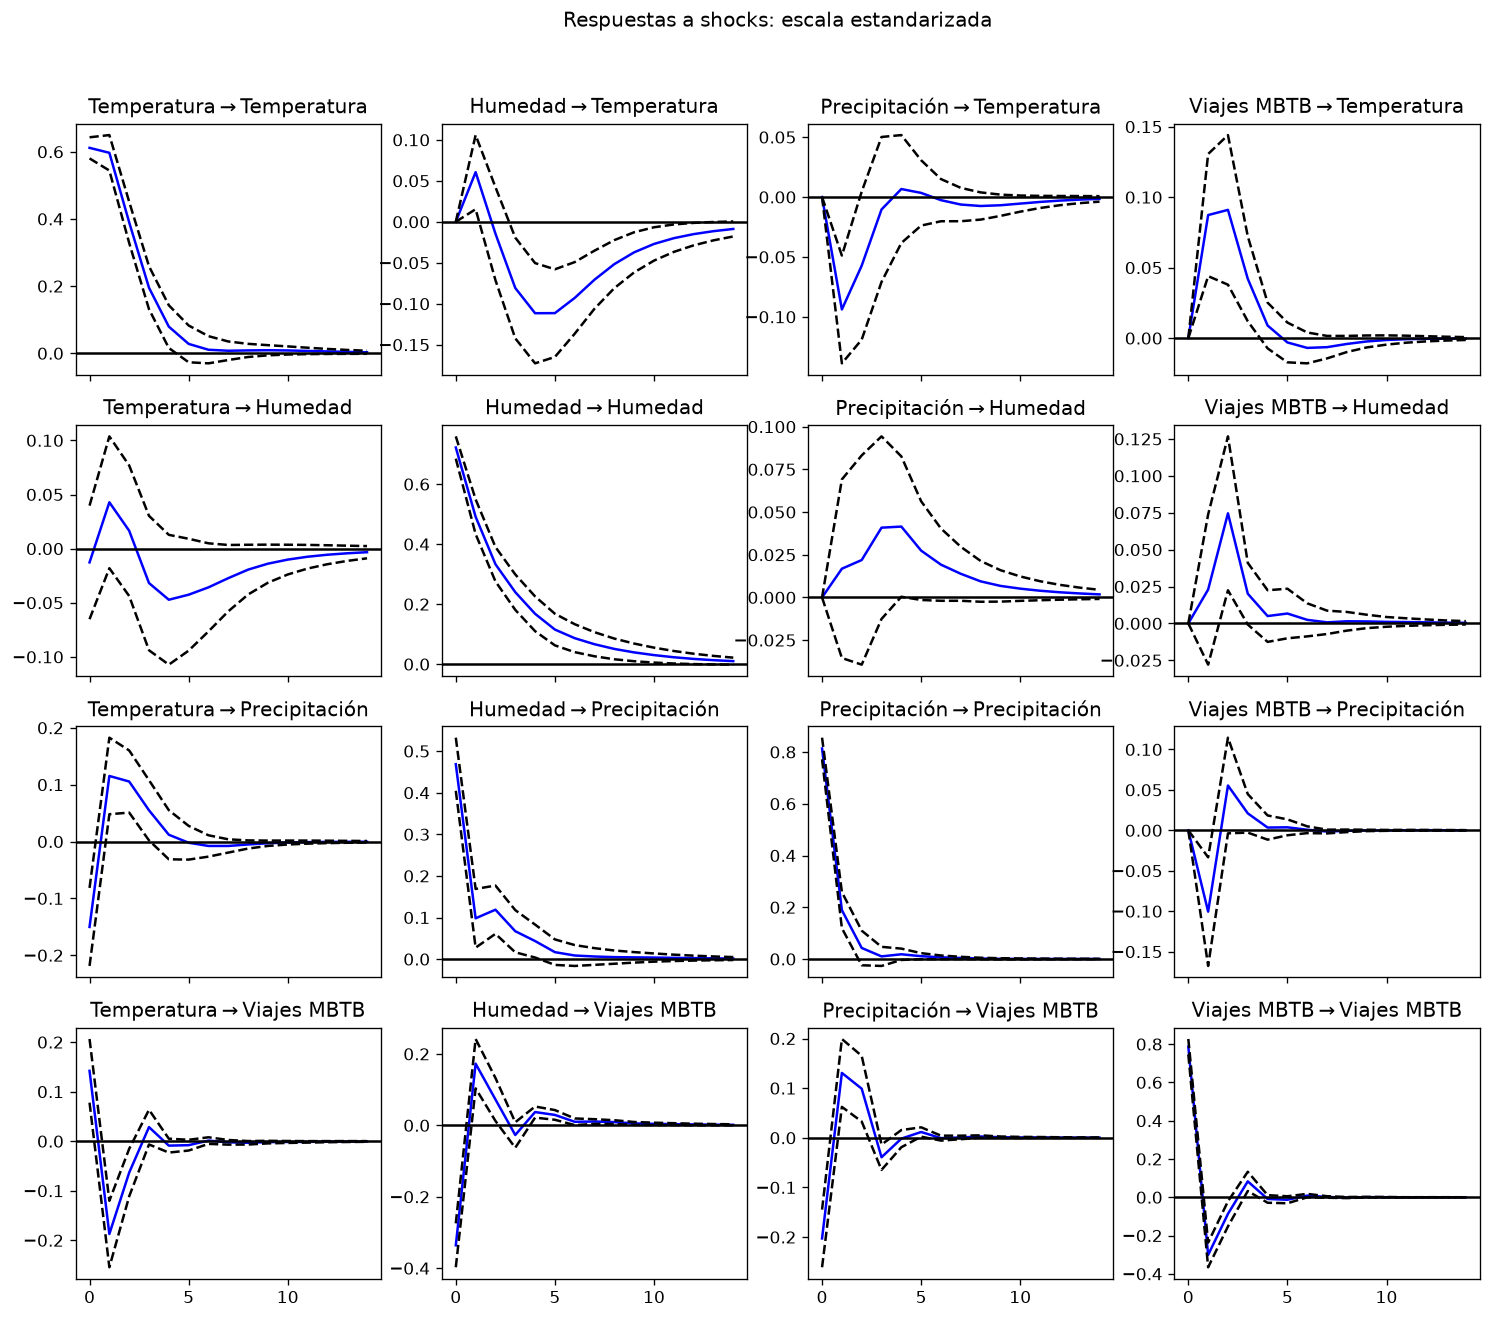

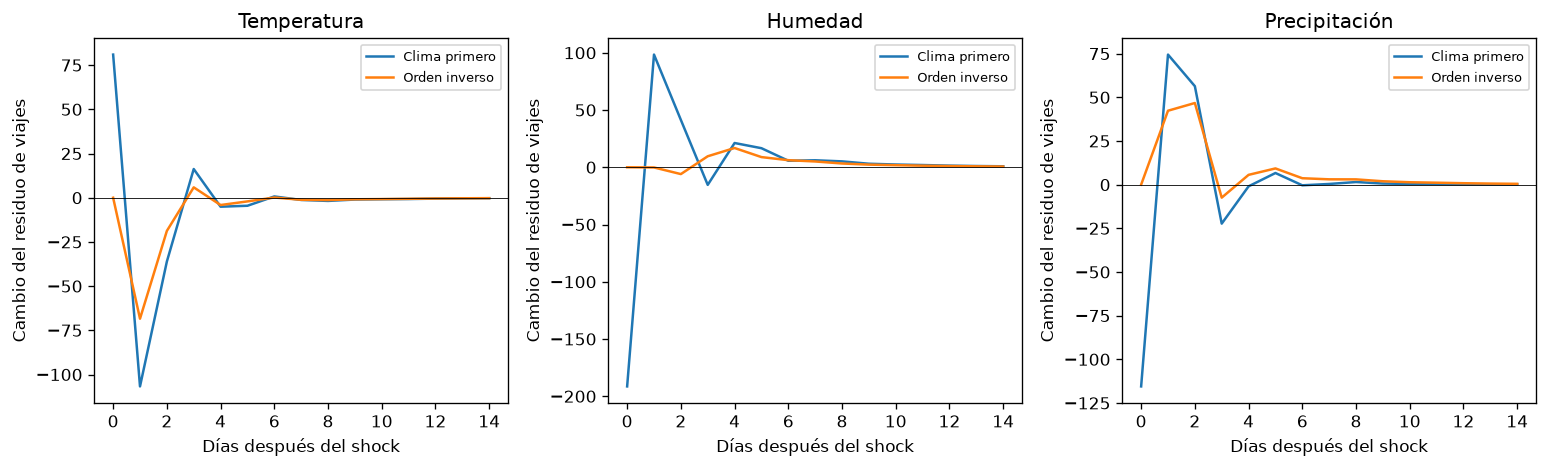

Relaciones predictivas detectadas con F y ajuste de Holm: Humedad → Temperatura; Precipitación → Temperatura; Viajes MBTB → Temperatura; Temperatura → Precipitación; Viajes MBTB → Precipitación; Temperatura → Viajes MBTB; Clima conjunto → Viajes MBTB.

Para **Temperatura**, la banda puntual del 95% de la respuesta del cambio diario de viajes excluye cero en los días **[0, 1, 2]**. Estas bandas no están ajustadas por mirar varios días a la vez.

Para un shock de **Temperatura**, la mayor respuesta acumulada absoluta del nivel de viajes dentro de 14 días es **80.97 viajes**, en el día **0**, bajo el orden adoptado.

Para **Humedad**, la banda puntual del 95% de la respuesta del cambio diario de viajes excluye cero en los días **[0, 1, 2, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14]**. Estas bandas no están ajustadas por mirar varios días a la vez.

Para un shock de **Humedad**, la mayor respuesta acumulada absoluta del nivel de viajes dentro de 14 días es **-191.41 viajes**, en el día **0**, bajo el orden adoptado.

Para **Precipitación**, la banda puntual del 95% de la respuesta del cambio diario de viajes excluye cero en los días **[0, 1, 2, 3, 5, 8]**. Estas bandas no están ajustadas por mirar varios días a la vez.

Para un shock de **Precipitación**, la mayor respuesta acumulada absoluta del nivel de viajes dentro de 14 días es **-115.52 viajes**, en el día **0**, bajo el orden adoptado.

In [2]:
from statsmodels.stats.multitest import multipletests
OUT=ROOT/'puntos/punto11';OUT.mkdir(exist_ok=True)
orden=['Temperatura','Humedad','Precipitación','Viajes MBTB']
panel=pd.DataFrame(series)[orden].loc[:'2024-12-31']
p=json.loads((ROOT/'puntos/punto10/resumen_var.json').read_text())['rezagos']
bundle=fit_var(panel,p=p);r=bundle['resultado']
if not r.is_stable(): raise RuntimeError('El VAR no es estable: no se interpreta su impulso-respuesta.')
filas=[]
for destino in orden:
    for origen in orden:
        if origen==destino:continue
        f=r.test_causality(destino,[origen],kind='f');w=r.test_causality(destino,[origen],kind='wald')
        filas.append({'origen':origen,'destino':destino,'F':f.test_statistic,'F_p':f.pvalue,'Wald_p':w.pvalue})
f=r.test_causality('Viajes MBTB',orden[:3],kind='f');w=r.test_causality('Viajes MBTB',orden[:3],kind='wald')
filas.append({'origen':'Clima conjunto','destino':'Viajes MBTB','F':f.test_statistic,'F_p':f.pvalue,'Wald_p':w.pvalue})
g=pd.DataFrame(filas)
for col in ['F_p','Wald_p']:
    rechazo,ajustado,_,_=multipletests(g[col],method='holm');g[col+'_Holm']=ajustado;g[col+'_rechaza']=rechazo
g.to_csv(OUT/'granger.csv',index=False);display(g.round(5))
instant=[]
for nombre in orden:
    q=r.test_inst_causality([nombre]);instant.append({'serie':nombre,'p_valor':q.pvalue})
instant=pd.DataFrame(instant);instant['p_Holm']=multipletests(instant.p_valor,method='holm')[1]
instant.to_csv(OUT/'instantanea.csv',index=False);display(instant.round(5))
irf=r.irf(14)
fig=irf.plot(orth=True,plot_stderr=True,stderr_type='asym',figsize=(13,11))
fig.suptitle('Respuestas a shocks: escala estandarizada',y=1.01)
fig.savefig(OUT/'impulso_respuesta.png',bbox_inches='tight');plt.show();plt.close(fig)
filas_irf=[]
errores_irf=irf.stderr(orth=True)
for h in range(15):
    for i,destino in enumerate(orden):
        for j,origen in enumerate(orden):
            filas_irf.append({'dia':h,'origen':origen,'destino':destino,
                'respuesta_estandarizada':irf.orth_irfs[h,i,j],
                'inferior95':irf.orth_irfs[h,i,j]-1.96*errores_irf[h,i,j],
                'superior95':irf.orth_irfs[h,i,j]+1.96*errores_irf[h,i,j],
                'respuesta_unidad_original':irf.orth_irfs[h,i,j]*bundle['escala'][destino]})
tabla_irf=pd.DataFrame(filas_irf)
mask=tabla_irf.destino.eq('Viajes MBTB')
tabla_irf.loc[mask,'respuesta_nivel_viajes']=tabla_irf[mask].groupby('origen').respuesta_unidad_original.cumsum()
tabla_irf.to_csv(OUT/'impulso_respuesta.csv',index=False)
inverso=orden[::-1];br=fit_var(panel[inverso],p=p);ir2=br['resultado'].irf(14)
fig,axes=plt.subplots(1,3,figsize=(13,4))
for ax,clima in zip(axes,orden[:3]):
    a=irf.orth_irfs[:,orden.index('Viajes MBTB'),orden.index(clima)]*bundle['escala']['Viajes MBTB']
    b=ir2.orth_irfs[:,inverso.index('Viajes MBTB'),inverso.index(clima)]*br['escala']['Viajes MBTB']
    ax.plot(a,label='Clima primero');ax.plot(b,label='Orden inverso');ax.axhline(0,color='black',lw=.5)
    ax.set(title=clima,xlabel='Días después del shock',ylabel='Cambio del residuo de viajes');ax.legend(fontsize=8)
fig.tight_layout();fig.savefig(OUT/'sensibilidad_orden.png');plt.show();plt.close(fig)
hallazgos=g[g.F_p_rechaza]
if hallazgos.empty: display(Markdown('Ninguna relación supera el ajuste de Holm al 5% en las pruebas F.'))
else:
    display(Markdown('Relaciones predictivas detectadas con F y ajuste de Holm: '+ '; '.join(hallazgos.origen+' → '+hallazgos.destino)+'.'))
# Resumen descriptivo; no convierte el máximo observado en una prueba adicional.
for clima in orden[:3]:
    sub=tabla_irf[(tabla_irf.origen==clima)&(tabla_irf.destino=='Viajes MBTB')]
    dias=sub.loc[(sub.inferior95>0)|(sub.superior95<0),'dia'].tolist()
    display(Markdown(f'Para **{clima}**, la banda puntual del 95% de la respuesta del cambio diario de viajes excluye cero en los días **{dias}**. Estas bandas no están ajustadas por mirar varios días a la vez.'))
    valores=np.cumsum(irf.orth_irfs[:,3,orden.index(clima)]*bundle['escala']['Viajes MBTB'])
    h=int(np.argmax(np.abs(valores)))
    display(Markdown(f'Para un shock de **{clima}**, la mayor respuesta acumulada absoluta del nivel de viajes dentro de 14 días '
                     f'es **{valores[h]:.2f} viajes**, en el día **{h}**, bajo el orden adoptado.'))


## Conclusión

Las pruebas describen información predictiva dentro del modelo. No permiten afirmar que intervenir sobre el clima produciría el cambio mostrado en los viajes. Las respuestas dependen del orden de Cholesky, de los rezagos elegidos y de la calidad del ajuste. Las bandas no incluyen la incertidumbre de estimar previamente el calendario. Las pruebas F y Wald contrastan la misma hipótesis mediante aproximaciones diferentes; no son dos confirmaciones independientes.

**Referencia:** Statsmodels developers. (s. f.). [Vector autoregressions: impulso-respuesta y pruebas](https://www.statsmodels.org/stable/vector_ar.html).